# Project 5: Predicting Sales with Advertising Budget

### Project Goal
The primary goal of this project is to build a simple linear regression model to understand the relationship between advertising expenditure on different channels (TV, Radio, Newspaper) and sales. We will analyze the provided dataset, clean it, and train a model to predict sales based on the advertising budget.

### Learning Objectives
* Learn to load, inspect, and clean a dataset using the pandas library.
* Understand how to perform exploratory data analysis (EDA) through visualizations to uncover trends.
* Identify and handle outliers in the data.
* Prepare data for machine learning by splitting it into training and testing sets.
* Build, train, and evaluate a Linear Regression model using scikit-learn.
* Interpret key performance metrics like MSE, MAE, and R-squared.
* Visualize the model's predictions against actual values.

---

### 1. Importing Necessary Libraries




In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("C:/Users/DELL/Downloads/Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.isna().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
col= ['ID', 'TV Ad Budget','Radio Ad Budget','Newspaper Ad Budget','Sales']
df.columns=col
df

,ID,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [10]:
df.describe()

,ID,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


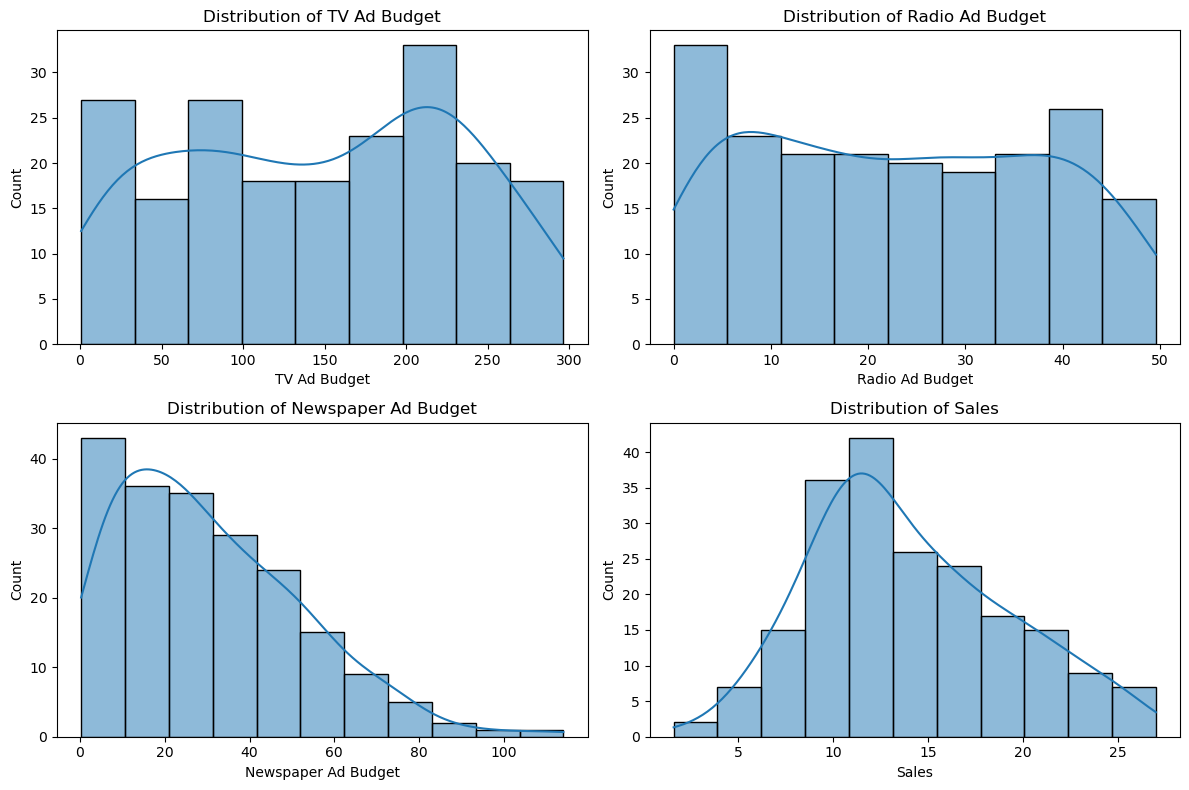

In [11]:
numerical_cols = ['TV Ad Budget','Radio Ad Budget','Newspaper Ad Budget','Sales']

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

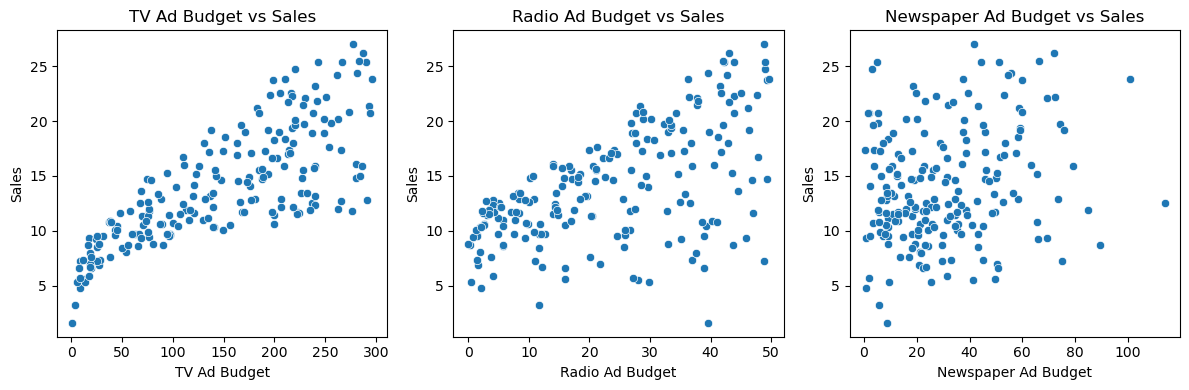

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x='TV Ad Budget', y='Sales', data=df)
plt.title('TV Ad Budget vs Sales')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Radio Ad Budget', y='Sales', data=df)
plt.title('Radio Ad Budget vs Sales')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Newspaper Ad Budget', y='Sales', data=df)
plt.title('Newspaper Ad Budget vs Sales')
plt.tight_layout()
plt.show()

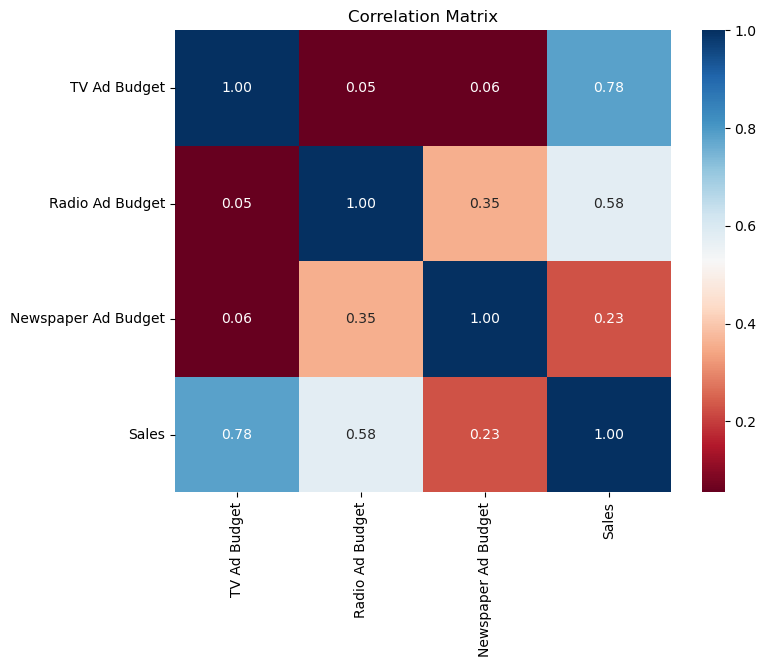

In [13]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

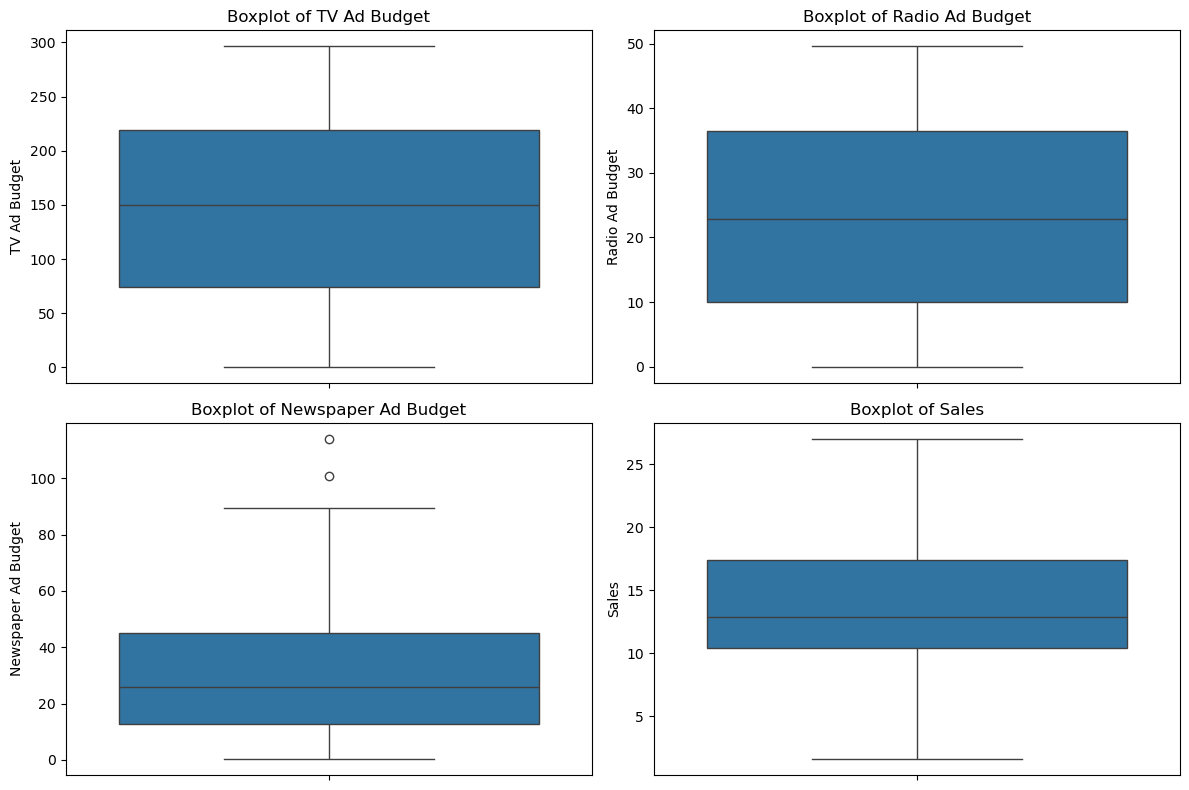

In [14]:
# With Outliers

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()

In [15]:
# remove Outliers

Q1 = df['Newspaper Ad Budget'].quantile(0.25)
Q3 = df['Newspaper Ad Budget'].quantile(0.75)
IQR = Q3 - Q1

l_bound = Q1 - 1.5 * IQR
u_bound = Q3 + 1.5 * IQR

print(l_bound)
print(u_bound)

-35.775000000000006
93.625


In [16]:
df_clean= df[(df['Newspaper Ad Budget'] >= l_bound) & (df['Newspaper Ad Budget'] <= u_bound)].copy()


In [17]:
df.shape

(200, 5)

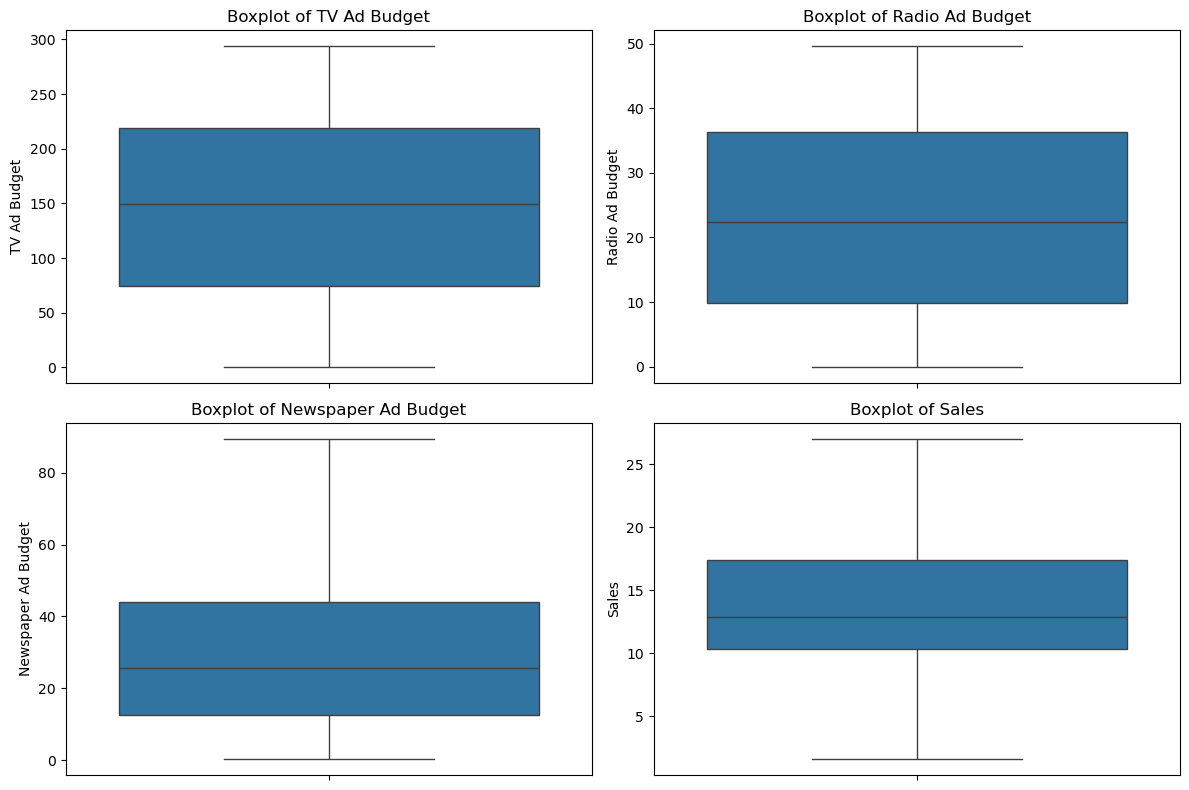

In [18]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()

Pair Plot of Numerical Features:


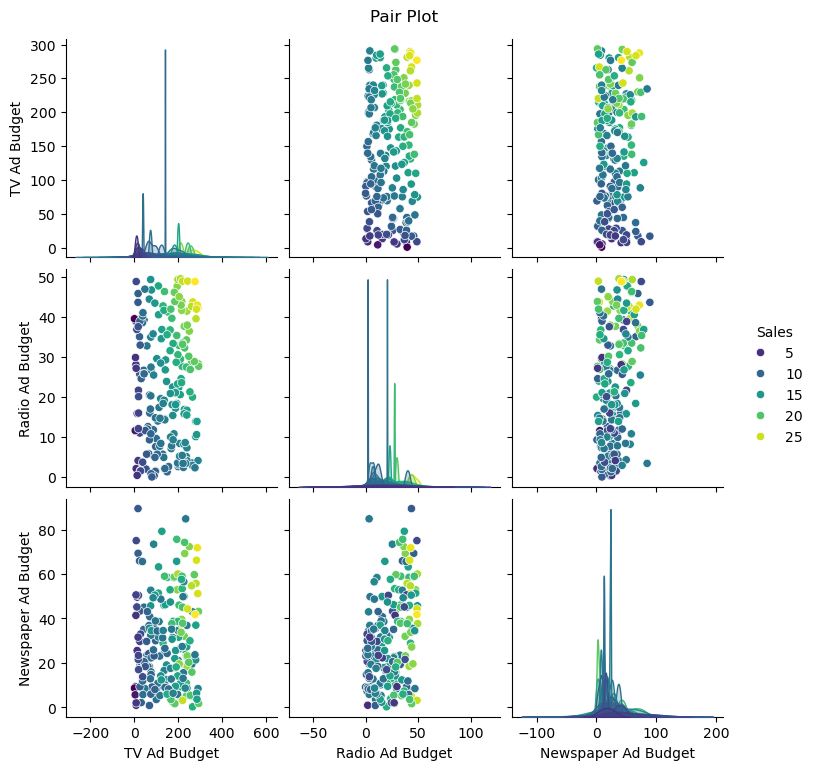

In [19]:
print("Pair Plot of Numerical Features:")
sns.pairplot(df_clean[numerical_cols], hue='Sales', palette='viridis')
plt.suptitle('Pair Plot', y=1.02)
plt.show()

In [20]:
X=df[['Newspaper Ad Budget','Radio Ad Budget','TV Ad Budget']]
y=df['Sales']

X_clean=df_clean[['Newspaper Ad Budget','Radio Ad Budget','TV Ad Budget']]
y_clean=df_clean['Sales']


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

In [22]:
# With Outliers and without scaling

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R^2: {r2}')

MSE: 3.174097353976105
MAE: 1.4607567168117606
R^2: 0.899438024100912


In [23]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [24]:
# with OutLiers With Scaling

model_sc = LinearRegression()
model_sc.fit(X_train_sc, y_train)

y_pred_sc = model_sc.predict(X_test_sc)

mse_sc = mean_squared_error(y_test, y_pred_sc)
mae_sc = mean_absolute_error(y_test, y_pred_sc)
r2_sc = r2_score(y_test, y_pred_sc)

print(f'MSE: {mse_sc}')
print(f'MAE: {mae_sc}')
print(f'R^2: {r2_sc}')



MSE: 3.174097353976106
MAE: 1.4607567168117601
R^2: 0.8994380241009119


In [25]:
# Without Outliers without Scaling

model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean)

mse_clean = mean_squared_error(y_test_clean, y_pred_clean)
mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
r2_clean = r2_score(y_test_clean, y_pred_clean)

print(f'MSE: {mse_clean}')
print(f'MAE: {mae_clean}')
print(f'R^2: {r2_clean}')


MSE: 2.740911906689996
MAE: 1.2497394075236383
R^2: 0.8989454779619588


In [26]:
scalar_clean = StandardScaler()
X_train_clean_sc = scalar_clean.fit_transform(X_train_clean)
X_test_clean_sc = scalar_clean.transform(X_test_clean)

In [27]:
# Without Outliers with Scaling

model_clean_sc = LinearRegression()
model_clean_sc.fit(X_train_clean_sc, y_train_clean)

y_pred_clean_sc = model_clean_sc.predict(X_test_clean_sc)

mse_clean_sc = mean_squared_error(y_test_clean, y_pred_clean_sc)
mae_clean_sc = mean_absolute_error(y_test_clean, y_pred_clean_sc)
r2_clean_sc = r2_score(y_test_clean, y_pred_clean_sc)

print(f'MSE: {mse_clean_sc}')
print(f'MAE: {mae_clean_sc}')
print(f'R^2: {r2_clean_sc}')

MSE: 2.7409119066899974
MAE: 1.2497394075236397
R^2: 0.8989454779619587


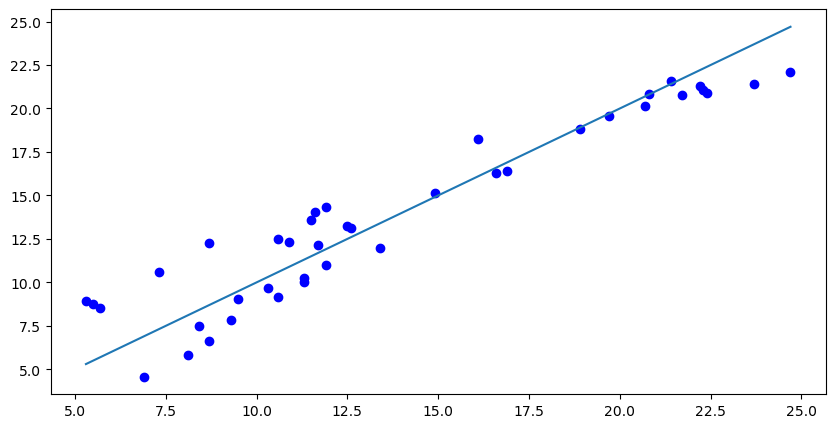

In [28]:
# with OutLiers Without Scaling

plt.figure(figsize =(10,5))
plt.scatter(y_test, y_pred,color = 'blue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.show()

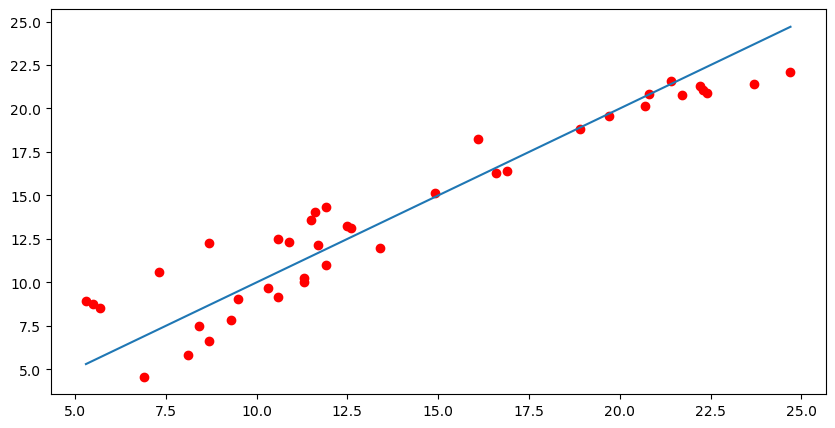

In [29]:
# With Outliers with Scaling

plt.figure(figsize =(10,5))
plt.scatter(y_test, y_pred_sc,color = 'red')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.show()

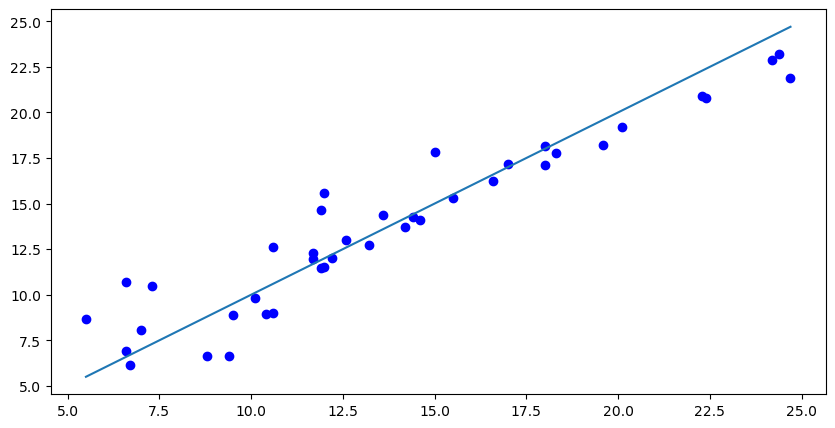

In [30]:
# without Outliers without Scaling

plt.figure(figsize =(10,5))
plt.scatter(y_test_clean, y_pred_clean,color = 'blue')
plt.plot([y_test_clean.min(), y_test_clean.max()],[y_test_clean.min(), y_test_clean.max()])
plt.show()

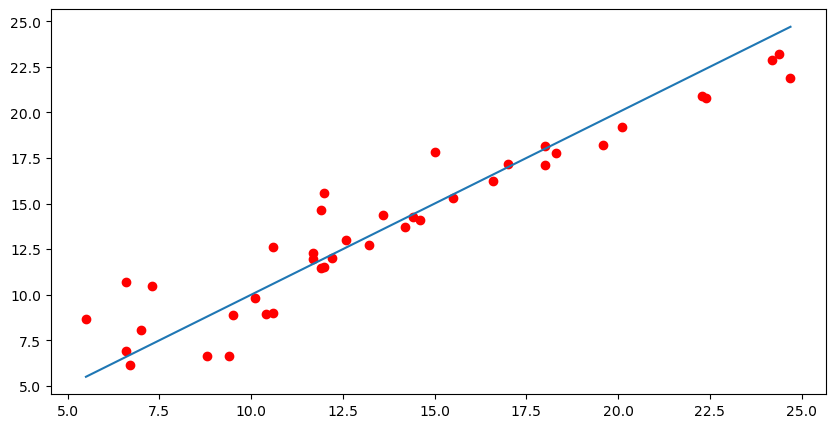

In [31]:
# without Outliers with Scaling

plt.figure(figsize =(10,5))
plt.scatter(y_test_clean, y_pred_clean_sc,color = 'red')
plt.plot([y_test_clean.min(), y_test_clean.max()],[y_test_clean.min(), y_test_clean.max()])
plt.show()

### 6. Conclusion
This project successfully demonstrated the process of building a linear regression model to predict sales from advertising budgets. Through exploratory data analysis, we found that TV advertising has the strongest correlation with sales. We also identified and removed outliers in the newspaper advertising data, which led to a model with lower prediction errors. The final model was able to explain approximately 90% of the variance in sales, indicating a strong predictive capability.